# Low-Dimensional Performance Experimant

Test MoLA against traditional CDMs on the low-dimensional fraction-subtraction dataset on various performance metrics.

In [1]:
%load_ext autoreload
%autoreload

In [2]:
# Allows import of modules from src/ in root
%cd ..

/Users/marialentini/Library/CloudStorage/OneDrive-Pearson/Research/Mixture-of-Latent-Archetypes


## Prepare Datasets

Download the fraction-subtraction dataset. Generate random train/test splits.

In [3]:
from src.utils.datasets import download_frac_subtr_to_pandas
import rpy2.robjects as ro

# Download fraction-subtraction datasets
X_df = download_frac_subtr_to_pandas('fraction.subtraction.data')
Q_df = download_frac_subtr_to_pandas('fraction.subtraction.qmatrix')

from sklearn.model_selection import ShuffleSplit
ss = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)

splits = []
for train_idx, test_idx in ss.split(X_df):
    X_train_df = X_df.iloc[train_idx]
    X_test_df = X_df.iloc[test_idx]
    splits.append((X_train_df, X_test_df))

# Get the citation object
citation = ro.r('citation("CDM")')
citation = ro.r('toBibtex(citation("CDM"))')

## Run Experiment

Train CDMs (DINA, GDINA and HO-DINA) and MoLA on all train/test splits.

In [4]:
import pandas as pd
import numpy as np
from src.experiments.low_dim import fit_mola, run_experiment

In [5]:
%%capture
final_results = []

# Fit classical CDMs
for model_name in ["DINA", "GDINA", "HO-DINA"]:
    result = run_experiment(model_name, splits, Q_df)
    final_results.append(result)

# Fit MoLA
result = fit_mola(splits, Q_df)
final_results += result

## Compile Results Table

Saves results to results/ folder in `low-dim-results.csv`.

In [6]:
results_df = pd.DataFrame([
    {
        # "Model": result['model'],
        "auc_train": np.mean(result['auc_train']),
        "Test AUC": np.mean(result['auc_test']),
        "nll_train": np.mean(result['nll_train']),
        "Test NLL": np.mean(result['nll_test']),
        "brier_train": np.mean(result['brier_train']),
        "Test Brier": np.mean(result['brier_test'])
    } 
    for result in final_results
])

results_df.to_csv('./results/low-dim-results.csv')
results_df.round(3)

,auc_train,Test AUC,nll_train,Test NLL,brier_train,Test Brier
0,0.899,0.893,0.274,0.278,0.128,0.131
1,0.925,0.904,0.249,0.268,0.104,0.118
2,0.912,0.903,0.289,0.296,0.111,0.117
3,0.914,0.903,0.329,0.336,0.114,0.121


## Visualize Callibration

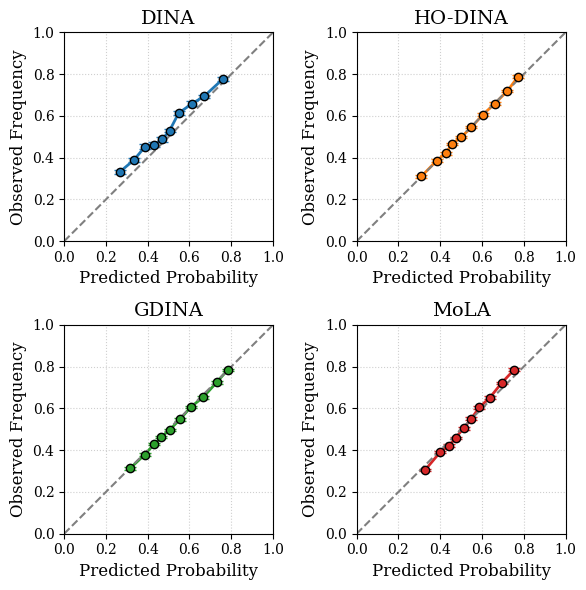

In [7]:
from src.experiments.low_dim import plot_calibrations

model_names = ["DINA", "HO-DINA", "GDINA", "MoLA"]
plot_calibrations(final_results, model_names, n_bins=10)